# Assignment 2

In this assignment you will create a coordinate-based multilayer perceptron in numpy from scratch. For each input image coordinate $(x,y)$, the model predicts the associated color $(r,g,b)$.

![Network diagram](https://user-images.githubusercontent.com/3310961/85066930-ad444580-b164-11ea-9cc0-17494679e71f.png)

You will then compare the following input feature mappings $\gamma (\mathbf{v})$.

- No mapping: $\gamma(\mathbf{v})= \mathbf{v}$. 

- Basic mapping: $\gamma(\mathbf{v})=\left[ \cos(2 \pi \mathbf{v}),\sin(2 \pi \mathbf{v}) \right]^\mathrm{T}$. (Note that the comma indicates a concatenation along the feature dimension.)

- Gaussian Fourier feature mapping: $\gamma(\mathbf{v})= \left[ \cos(2 \pi \mathbf B \mathbf{v}), \sin(2 \pi \mathbf B \mathbf{v}) \right]^\mathrm{T}$, 
where each entry in $\mathbf B \in \mathbb R^{m \times d}$ is sampled from $\mathcal N(0,\sigma^2)$. You should show results for $\sigma$ = 1 and 10. The starter code uses $m = s / 2$, where $s$ is the image side length in pixels; you can leave this alone, although you can also experiment with different values of $m$ and report your observations for extra credit.

Also, note that:
- You will implement the mappings in the helper functions `get_B_dict` and `input_mapping`. 
- The basic mapping can be considered a case where $\mathbf B \in \mathbb R^{2 \times 2}$ is the identity matrix. 
- For this assignment, $d$ is 2 because the input coordinates are in two dimensions.
- For SGD with the default hyperparameters, the expected reconstructions will be blurry to some extent.

Source: https://bmild.github.io/fourfeat/ 
This assignment is inspired by and built off of the authors' demo. 

## Setup

### (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. Replace the path below with the path in your Google Drive to the uploaded assignment folder. Mounting to Google Drive will allow you to access the other .py files in the assignment folder and save outputs to this folder.

In [2]:
# you will be prompted with a window asking to grant permissions
# click connect to google drive, choose your account, and click allow
from google.colab import drive
drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google'

In [ ]:
# TODO: fill in the path in your Google Drive in the string below
# Note: do not escape slashes or spaces in the path string
import os
datadir = "/content/assignment2"
if not os.path.exists(datadir):
  !ln -s "/content/drive/My Drive/path/to/your/assignment2/" $datadir
os.chdir(datadir)
!pwd

### Imports

In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, imageio
import cv2
import numpy as np

# imports /content/assignment2/models/neural_net.py if you mounted correctly 
from models.neural_net import NeuralNetwork

# makes sure your NeuralNetwork updates as you make changes to the .py file
%load_ext autoreload
%autoreload 2

# sets default size of plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)  

ModuleNotFoundError: No module named 'cv2'

## Helper Functions

### Image Data and Feature Mappings (Fill in TODOs)

In [34]:
# Data loader - already done for you
def get_image(size=512, \
              image_url='https://bmild.github.io/fourfeat/img/lion_orig.png'):

  # Download image, take a square crop from the center  
  img = imageio.imread(image_url)[..., :3] / 255.
  c = [img.shape[0]//2, img.shape[1]//2]
  r = 256
  img = img[c[0]-r:c[0]+r, c[1]-r:c[1]+r]

  if size != 512:
    img = cv2.resize(img, (size, size))

  plt.imshow(img)
  plt.show()

  # Create input pixel coordinates in the unit square
  coords = np.linspace(0, 1, img.shape[0], endpoint=False)
  x_test = np.stack(np.meshgrid(coords, coords), -1)
  test_data = [x_test, img]
  train_data = [x_test[::2, ::2], img[::2, ::2]]

  return train_data, test_data

In [35]:
# Create the mappings dictionary of matrix B -  you will implement this
def get_B_dict(size):
  mapping_size = size // 2
  B_dict = {}
  B_dict['none'] = None
  
  # add B matrix for basic, gauss_1.0, gauss_10.0
  # TODO implement this
  B_dict['basic'] = np.eye(2)
  B_dict['gauss_1.0'] = np.random.normal(loc=0.0, scale=1.0, size=(mapping_size, 2))
  B_dict['gauss_10.0'] = np.random.normal(loc=0.0, scale=10.0, size=(mapping_size, 2))

  return B_dict

In [36]:
# Given tensor x of input coordinates, map it using B - you will implement
def input_mapping(x, B):
  if B is None:
    # "none" mapping - just returns the original input coordinates
    return x
  else:
    # "basic" mapping and "gauss_X" mappings project input features using B
    # TODO implement this
    proj = x @ B.T
    return np.concatenate(
        [np.cos(2 * np.pi * proj), np.sin(2 * np.pi * proj)], axis=-1
    )

### MSE Loss and PSNR Error (Fill in TODOs)

For the MSE loss, you should implement the following:

MSE = $0.5 \frac{1}{NC} \sum \limits_{i=1}^N \sum \limits_{j=1}^C (y_{ij} - p_{ij})^2$

where $y$ and $p$ are of shape $(N, C)$.

In [37]:
def mse(y, p):
  # TODO implement this
  # make sure it is consistent with your implementation in neural_net.py
  res = 0.5 * np.mean((y - p) ** 2)
  return res

def psnr(y, p):
  return -10 * np.log10(2.*mse(y, p))

/var/folders/wh/xw47m9f92xz89krbf6pcs4nr0000gn/T/ipykernel_87981/2979632171.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_url)[..., :3] / 255.


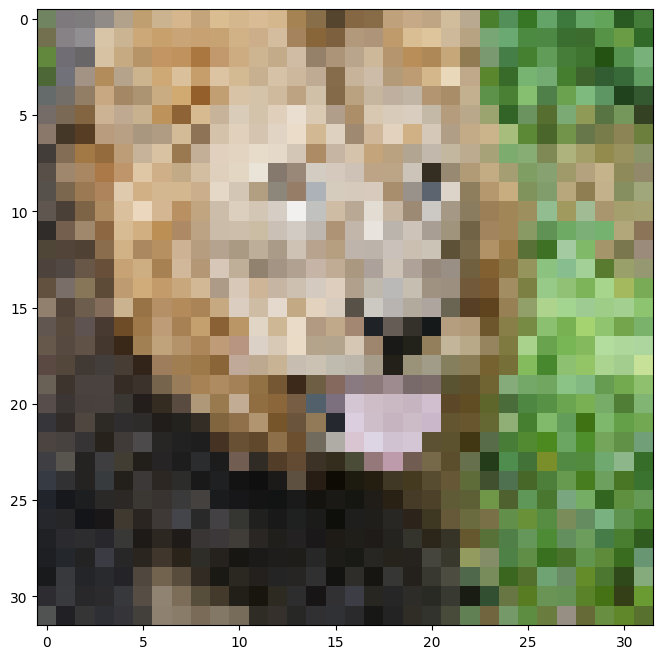

In [38]:
size = 32
train_data, test_data = get_image(size)

The default hyperparameters are as follows:
- number of layers: 4
- hidden layer size: 256
- number of epochs: 500
- learning rate: 0.1

You should implement SGD (i.e., one training example per weight update), and thus a mini-batch hyperparameter is not needed.

In [39]:
num_layers = 4
output_size = 3

hidden_size = 256
epochs = 500
learning_rate = 0.1

B_dict = get_B_dict(size)

print('B_dict items:')
for k,v in B_dict.items():
    print('\t',k,np.array(v).shape)

B_dict items:
	 none ()
	 basic (2, 2)
	 gauss_1.0 (16, 2)
	 gauss_10.0 (16, 2)


In [40]:
# Apply the input feature mapping to the train and test data - already done for you
def get_input_features(B_dict, mapping):
  # mapping is the key to the B_dict, which has the value of B
  # B is then used with the function `input_mapping` to map x  
  y_train = train_data[1].reshape(-1, output_size)
  y_test = test_data[1].reshape(-1, output_size)
  X_train = input_mapping(train_data[0].reshape(-1, 2), B_dict[mapping])
  X_test = input_mapping(test_data[0].reshape(-1, 2), B_dict[mapping])
  return X_train, y_train, X_test, y_test

### Plotting and video helper functions (you don't need to change anything here)

In [41]:
def plot_training_curves(train_loss, train_psnr, test_psnr):
  # plot the training loss
  plt.subplot(2, 1, 1)
  plt.plot(train_loss)
  plt.title('MSE history')
  plt.xlabel('Iteration')
  plt.ylabel('MSE Loss')

  # plot the training and testing psnr
  plt.subplot(2, 1, 2)
  plt.plot(train_psnr, label='train')
  plt.plot(test_psnr, label='test')
  plt.title('PSNR history')
  plt.xlabel('Iteration')
  plt.ylabel('PSNR')
  plt.legend()

  plt.tight_layout()
  plt.show()

def plot_reconstruction(p, y):
  p_im = p.reshape(size,size,3)
  y_im = y.reshape(size,size,3)

  plt.figure(figsize=(12,6))

  # plot the reconstruction of the image
  plt.subplot(1,2,1), plt.imshow(p_im), plt.title("reconstruction")

  # plot the ground truth image
  plt.subplot(1,2,2), plt.imshow(y_im), plt.title("ground truth")

  print("Final Test MSE", mse(y, p))
  print("Final Test psnr",psnr(y, p))

def plot_reconstruction_progress(predicted_images, y, N=8):
  total = len(predicted_images)
  step = total // N
  plt.figure(figsize=(24, 4))

  # plot the progress of reconstructions
  chosen = list(range(0,total, step))[:N]

  for i, j in enumerate(chosen):
      plt.subplot(1, N+1, i+1)
      plt.imshow(predicted_images[j].reshape(size,size,3))
      plt.axis("off")
      plt.title(f"iter {j}")

  # plot ground truth image
  plt.subplot(1, N+1, N+1)
  plt.imshow(y.reshape(size,size,3))
  plt.title('GT')
  plt.axis("off")
  plt.show()

def plot_feature_mapping_comparison(outputs, gt):
  # plot reconstruction images for each mapping
  plt.figure(figsize=(24, 4))
  N = len(outputs)
  for i, k in enumerate(outputs):
      plt.subplot(1, N+1, i+1)
      plt.imshow(outputs[k]['pred_imgs'][-1].reshape(size, size, -1))
      plt.title(k)
  plt.subplot(1, N+1, N+1)
  plt.imshow(gt)
  plt.title('GT')
  plt.show()

  # plot train/test error curves for each mapping
  iters = len(outputs[k]['train_psnrs'])
  plt.figure(figsize=(16, 6))
  plt.subplot(121)
  for i, k in enumerate(outputs):
      plt.plot(range(iters), outputs[k]['train_psnrs'], label=k)
  plt.title('Train error')
  plt.ylabel('PSNR')
  plt.xlabel('Training iter')
  plt.legend()
  plt.subplot(122)
  for i, k in enumerate(outputs):
      plt.plot(range(iters), outputs[k]['test_psnrs'], label=k)
  plt.title('Test error')
  plt.ylabel('PSNR')
  plt.xlabel('Training iter')
  plt.legend()
  plt.show()

  for k in outputs:
    print(f"Final Test PSNR for {k}", outputs[k]['test_psnrs'][-1])

# Save out video
def create_and_visualize_video(outputs, size=size, epochs=epochs, filename='training_convergence.mp4'):
  all_preds = np.concatenate([outputs[n]['pred_imgs'].reshape(epochs,size,size,3)[::25] for n in outputs], axis=-2)
  data8 = (255*np.clip(all_preds, 0, 1)).astype(np.uint8)
  f = os.path.join(filename)
  imageio.mimwrite(f, data8, fps=20)

  # Display video inline
  from IPython.display import HTML
  from base64 import b64encode
  mp4 = open(f, 'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

  N = len(outputs)
  if N == 1:
    return HTML(f'''
    <video width=256 controls autoplay loop>
          <source src="{data_url}" type="video/mp4">
    </video>
    ''')
  else:
    return HTML(f'''
    <video width=1000 controls autoplay loop>
          <source src="{data_url}" type="video/mp4">
    </video>
    <table width="1000" cellspacing="0" cellpadding="0">
      <tr>{''.join(N*[f'<td width="{1000//len(outputs)}"></td>'])}</tr>
      <tr>{''.join(N*['<td style="text-align:center">{}</td>'])}</tr>
    </table>
    '''.format(*list(outputs.keys())))

### Experiment Runner (Fill in TODOs)

In [42]:
def NN_experiment(X_train, y_train, X_test, y_test, input_size, num_layers,\
                  hidden_size, output_size, epochs,\
                  learning_rate, opt='SGD'):
    
    # Initialize a new neural network model
    hidden_sizes = [hidden_size] * (num_layers - 1)
    net = NeuralNetwork(input_size, hidden_sizes, output_size, num_layers, opt)

    # Variables to store performance for each epoch
    train_loss = np.zeros(epochs) # Will record average loss per epoch
    train_psnr = np.zeros(epochs)
    test_psnr = np.zeros(epochs)
    predicted_images = np.zeros((epochs, y_test.shape[0], y_test.shape[1]))

    N = X_train.shape[0]

    # For each epoch...
    for epoch in tqdm(range(epochs)):
        # Shuffle the dataset
        # TODO implement this
        permutations = np.random.permutation(N)
        X_train_shuffled = X_train[permutations]
        y_train_shuffled = y_train[permutations]

        # Training
        # For each pixel location...
        for x, y in zip(X_train, y_train):
            # Run the forward pass of the model to get a prediction
            # TODO implement this
            p = net.forward(x[np.newaxis, :])

            # Run the backward pass of the model to compute the loss
            # TODO implement this
            loss = net.backward(y[np.newaxis, :])

            # Update train_loss[epoch] for computing average loss
            # TODO implement this
            train_loss[epoch] += loss

            # Update the weights
            # TODO implement this
            net.update(lr=learning_rate)

        # Record PSNR of training pixels at the end of epoch
        # No need to run the backward pass here, just run one forward pass (but now on all the training pixels)
        # TODO: implement this
        train_loss[epoch] /= N
        p_train = net.forward(X_train)
        train_psnr[epoch] = psnr(y_train, p_train)

        # Update predicted_images[epoch] and record PSNR of testing pixels at end of epoch
        # No need to run the backward pass here, just run one forward pass (but now on all the testing pixels)
        # TODO: implement this
        p_test = net.forward(X_test)
        test_psnr[epoch] = psnr(y_test, p_test)
        predicted_images[epoch] = p_test

    return net, train_psnr, test_psnr, train_loss, predicted_images

# Low Resolution Reconstruction

#### Low Resolution Reconstruction - SGD - None Mapping

Using the default hyperparameters, for the low resolution reconstuction with
no feature mapping you should expect something like this:

![Low resolution reconstruction - None Mapping Example](images/low_res_none_example.png)

For verifying your implementation, the average test PSNR should reach approximately 18.

100%|██████████| 500/500 [00:17<00:00, 28.97it/s]


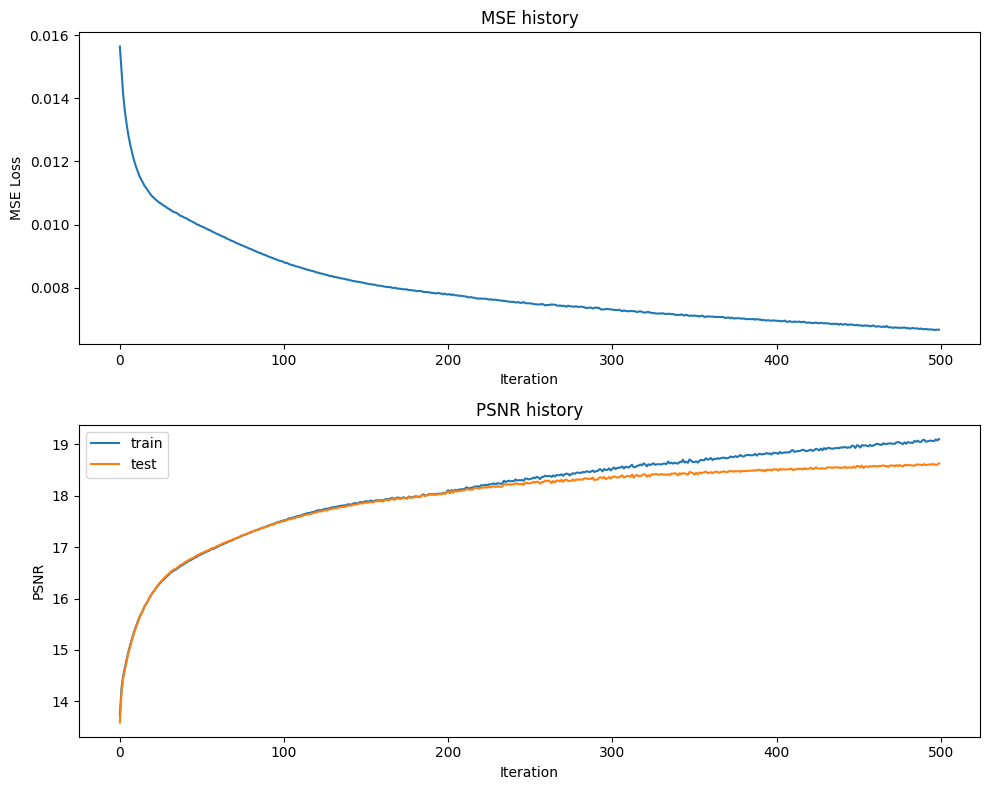

Final Test MSE 0.006847807594410569
Final Test psnr 18.634184550412918


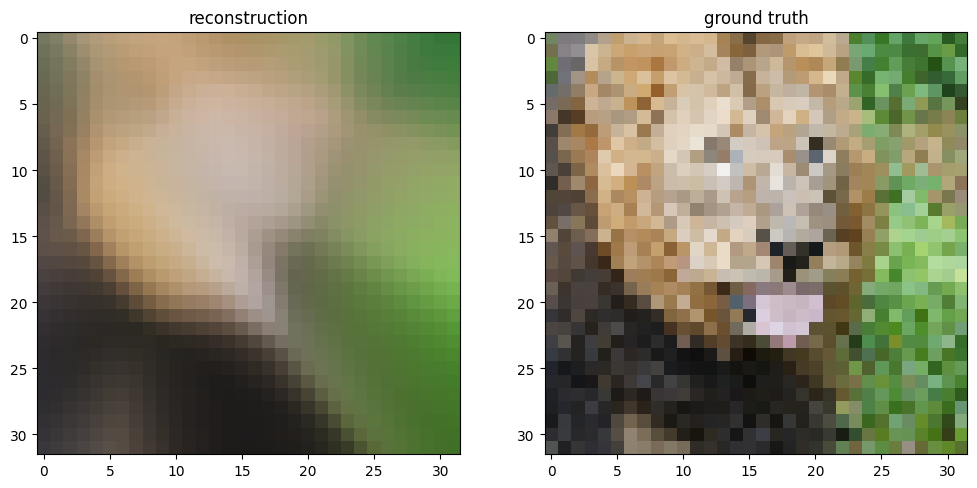

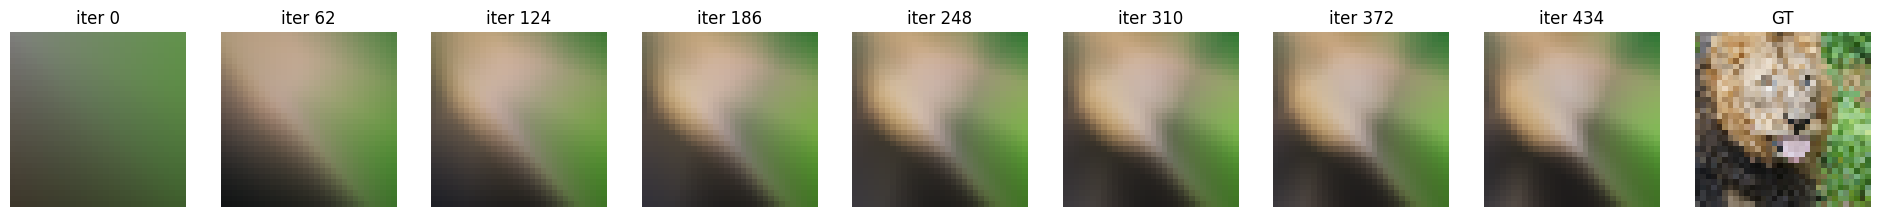

In [13]:
# get input features
# TODO utilize the get_input_features() helper function
X_train, y_train, X_test, y_test = get_input_features(B_dict, "none")

# run NN_experiment on input features
# TODO implement by using the NN_experiment() helper function
net, train_psnr, test_psnr, train_loss, predicted_images = NN_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    input_size=X_train.shape[1],
    num_layers=num_layers,
    hidden_size=hidden_size,
    output_size=output_size,
    epochs=epochs,
    learning_rate=learning_rate,
    opt='SGD'
)

# plot results of experiment
plot_training_curves(train_loss, train_psnr, test_psnr)
plot_reconstruction(net.forward(X_test), y_test)
plot_reconstruction_progress(predicted_images, y_test)

#### Reconstruction Process Video (Optional)
(For Fun!) Visualize the progress of training in a video 

In [14]:
# requires installing this additional dependency
!pip install imageio-ffmpeg


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
# single video example
create_and_visualize_video({"gauss": {"pred_imgs": predicted_images}}, filename="training_high_res_gauss.mp4")

#### Low Resolution Reconstruction - SGD - Various Input Mapping Strategies

Using the default hyperparameters, for the low resolution reconstuction with
feature mappings (basic and Gaussian with $\sigma$ = 1 and 10) you should expect something like this:

![Low resolution reconstruction - Feature Mapping Examples](images/feature_mapping_example_low_res.png)

For verifying your implementation, your test PSNR should reach approximately the following values:
- None: 18
- Basic: 19
- Gaussian ($\sigma$=1): 19
- Gaussian ($\sigma$=10): 13

In [16]:
def train_wrapper(mapping, size, num_layers, hidden_size, output_size, epochs,  learning_rate, opt='SGD'):
    # TODO implement me
    # makes it easy to run all your mapping experiments in a for loop
    # this will be similar to what you did previously in the last two sections
    B_dict = get_B_dict(size)
    X_train, y_train, X_test, y_test = get_input_features(B_dict, mapping)

    net, train_psnr, test_psnr, train_loss, predicted_images = NN_experiment(
        X_train,
        y_train,
        X_test,
        y_test,
        input_size=X_train.shape[1],
        num_layers=num_layers,
        hidden_size=hidden_size,
        output_size=output_size,
        epochs=epochs,
        learning_rate=learning_rate,
        opt=opt,
    )

    return {
        'net': net, 
        'train_psnrs': train_psnr, 
        'test_psnrs': test_psnr,
        'train_loss': train_loss,
        'pred_imgs': predicted_images
    }

In [17]:
outputs = {}
for k in tqdm(B_dict):
  print("training", k)
  outputs[k] = train_wrapper(k, size, num_layers, hidden_size, output_size, epochs, learning_rate, opt='SGD')

  0%|          | 0/4 [00:00<?, ?it/s]

training none


 25%|██▌       | 1/4 [00:17<00:52, 17.41s/it]

training basic


 50%|█████     | 2/4 [00:34<00:34, 17.48s/it]

training gauss_1.0


 75%|███████▌  | 3/4 [00:53<00:17, 17.98s/it]

training gauss_10.0


100%|██████████| 4/4 [01:12<00:00, 18.20s/it]


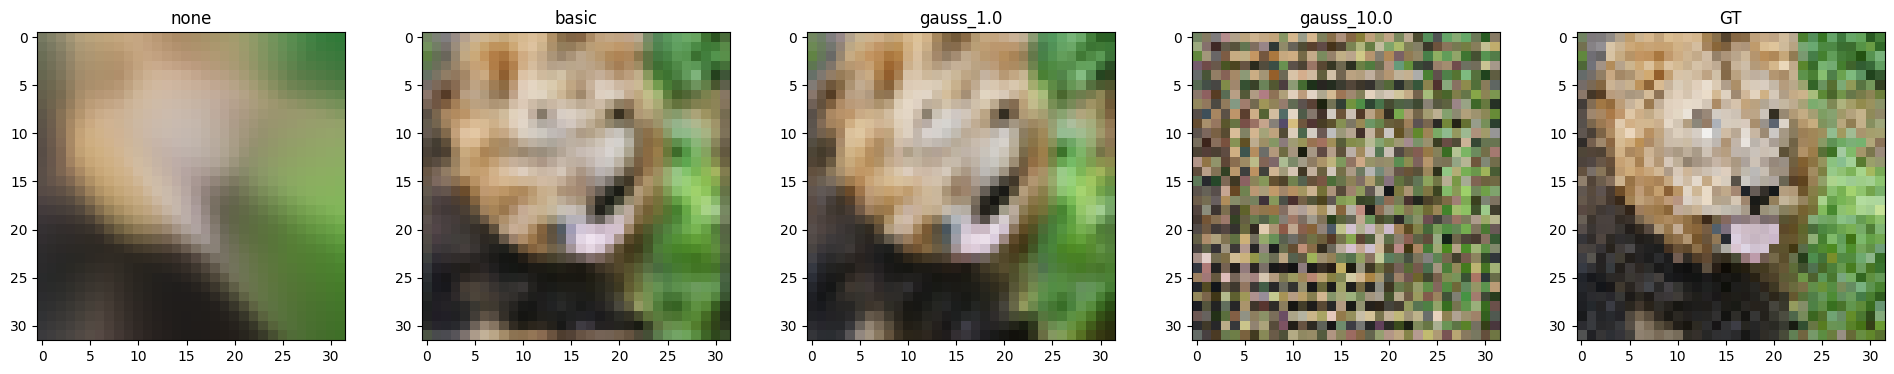

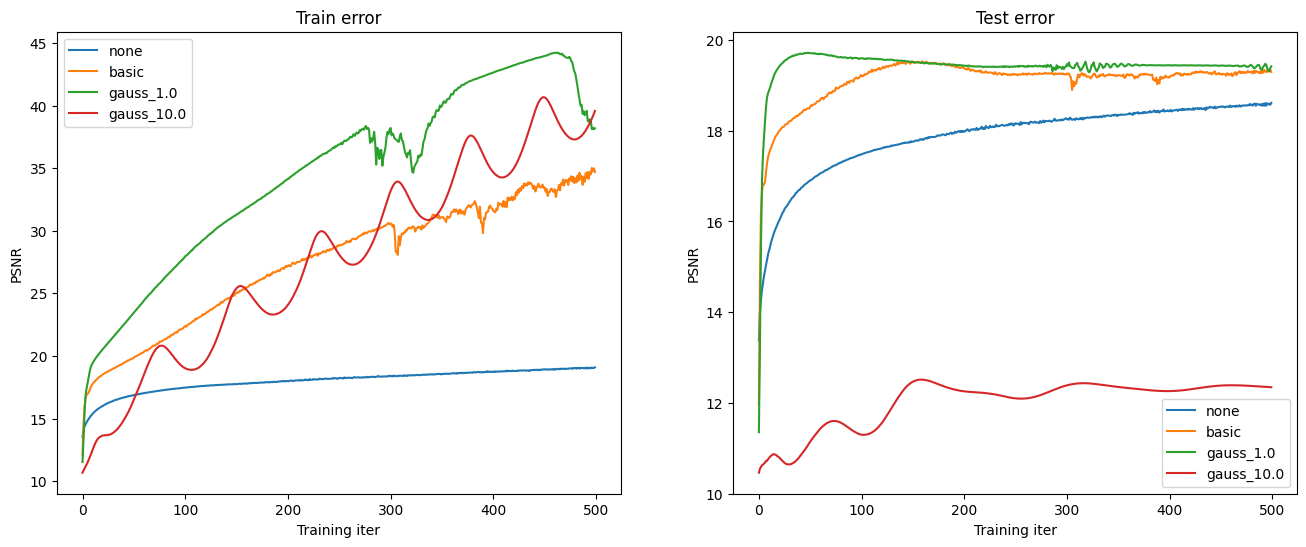

Final Test PSNR for none 18.61475507059883
Final Test PSNR for basic 19.295387178164976
Final Test PSNR for gauss_1.0 19.420344537380583
Final Test PSNR for gauss_10.0 12.345737939301124


In [18]:
# If you did everything correctly so far, this should output a nice figure you can use in your report.
# Note: With default settings, you should expect the Gaussian Fourier feature mapping to perform
# slightly better than the none and basic mappings, capturing more fine details in the reconstruction.
# However, the reconstruction will still be blurry to some extent and will not yield a great
# reconstruction with the default hyperparameters.
plot_feature_mapping_comparison(outputs, y_test.reshape(size,size,3))

#### Reconstruction Process Video (Optional)
(For Fun!) Visualize the progress of training in a video 

In [19]:
# multi video example
create_and_visualize_video(outputs, epochs=epochs, size=size)

,,,
none,basic,gauss_1.0,gauss_10.0


# High Resolution Reconstruction

#### High Resolution Reconstruction - SGD - Various Input Mapping Strategies

Repeat the previous experiment, but at the higher resolution. We have you first experiment with the lower resolution since it is faster to train and debug. Additionally, you will see how the mapping strategies perform better or worse at the two different input resolutions. 


Using the default hyperparameters, for the high resolution reconstuctions you should expect something like this:

![High resolution reconstructions](images/feature_mapping_example_high_res.png)

For verifying your implementation, your test PSNR should reach approximately the following values:
- None: 20
- Basic: 22
- Gaussian ($\sigma$=1): 23
- Gaussian ($\sigma$=10): 22

/var/folders/wh/xw47m9f92xz89krbf6pcs4nr0000gn/T/ipykernel_87981/2979632171.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_url)[..., :3] / 255.


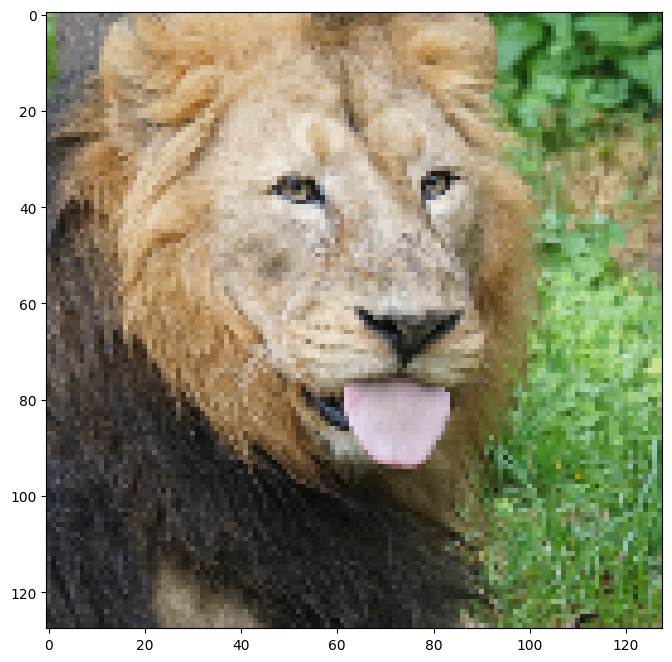

B_dict items:
	 none ()
	 basic (2, 2)
	 gauss_1.0 (64, 2)
	 gauss_10.0 (64, 2)


In [20]:
# load hi-res image
size = 128
train_data, test_data = get_image(size)

B_dict = get_B_dict(size)

print('B_dict items:')
for k,v in B_dict.items():
    print('\t',k,np.array(v).shape)

In [21]:
outputs = {}
for k in tqdm(B_dict):
  print("training", k)
  outputs[k] = train_wrapper(k,size, num_layers, hidden_size, output_size, epochs, learning_rate, opt='SGD')

  0%|          | 0/4 [00:00<?, ?it/s]

training none


 25%|██▌       | 1/4 [04:34<13:43, 274.48s/it]

training basic


 50%|█████     | 2/4 [09:10<09:11, 275.63s/it]

training gauss_1.0


 75%|███████▌  | 3/4 [14:34<04:57, 297.47s/it]

training gauss_10.0


100%|██████████| 4/4 [19:50<00:00, 297.70s/it]


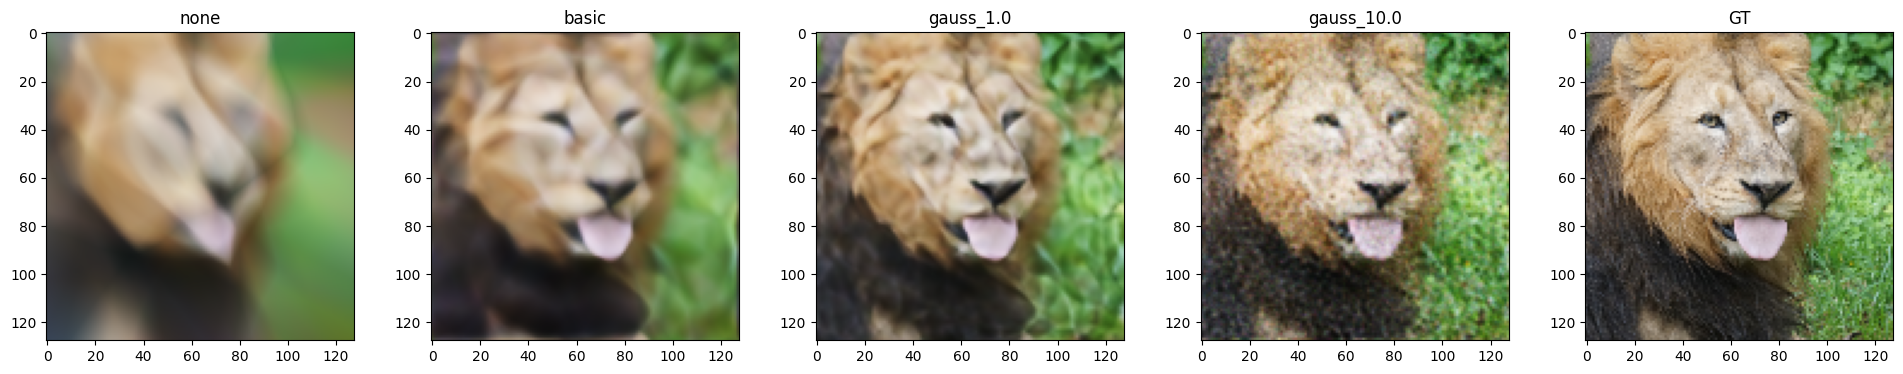

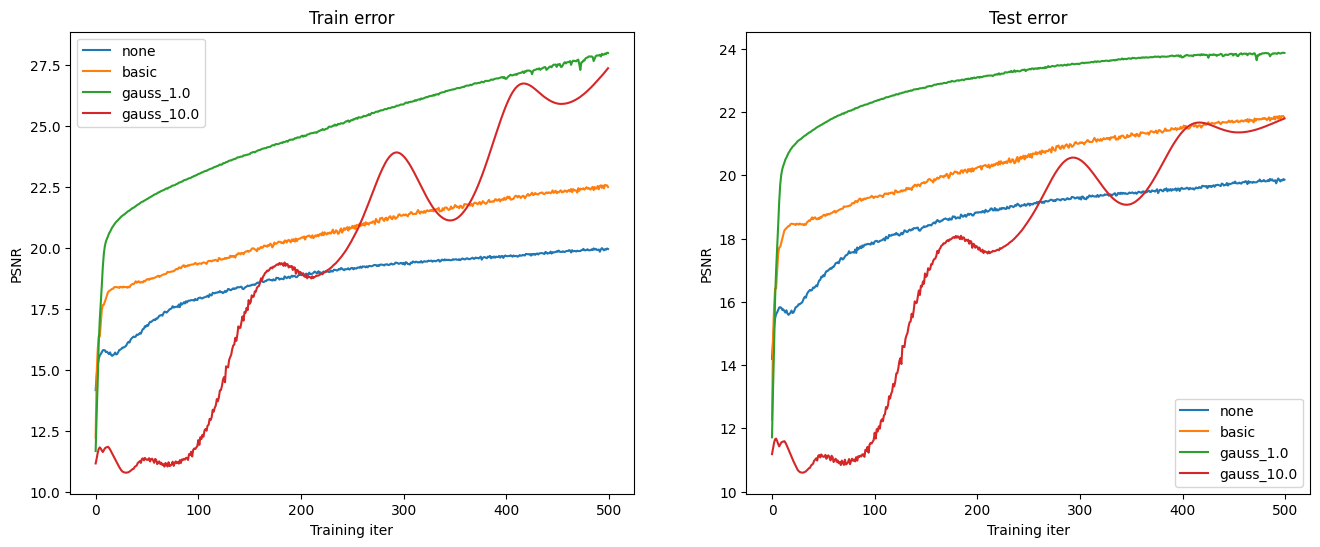

Final Test PSNR for none 19.858298941650435
Final Test PSNR for basic 21.81160993559747
Final Test PSNR for gauss_1.0 23.864552843908374
Final Test PSNR for gauss_10.0 21.792607532442304


In [22]:
_, _, _, y_test = get_input_features(B_dict, "none")  # for getting y_test

# If you did everything correctly so far, this should output a nice figure you can use in your report.
# Similar to the low resolution case, the Gaussian Fourier feature mapping should perform slightly
# better than the none and basic mappings, preserving more details. However, the reconstruction
# will still appear blurry to some extent and will not be a great reconstruction with default settings.
plot_feature_mapping_comparison(outputs, y_test.reshape(size,size,3))

#### Reconstruction Process Video (Optional)
(For Fun!) Visualize the progress of training in a video 

In [ ]:
# multi video example
create_and_visualize_video(outputs, epochs=epochs, size=size)

,,,
none,basic,gauss_1.0,gauss_10.0


#### High Resolution Reconstruction - SGD - Image of Your Choice

When choosing an image, select one that you think will give you interesting results or a better insight into the performance of different feature mappings and record at least one interesting insight you gained.

/var/folders/wh/xw47m9f92xz89krbf6pcs4nr0000gn/T/ipykernel_87981/2979632171.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_url)[..., :3] / 255.


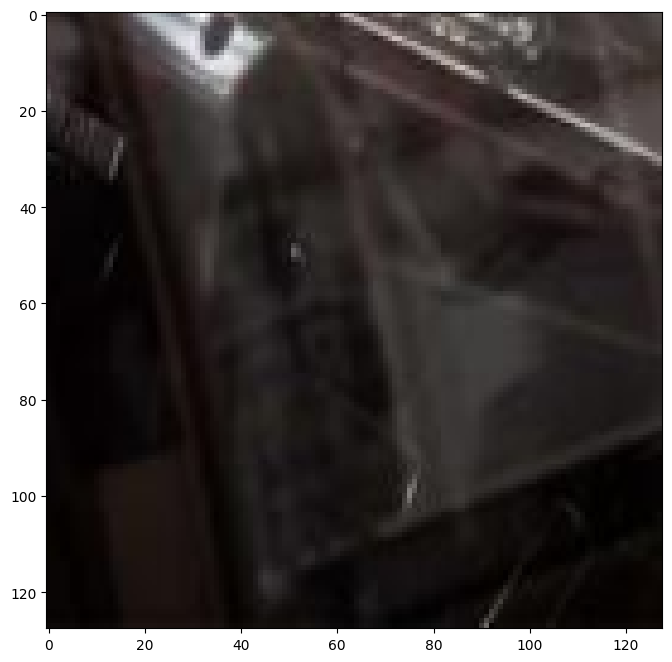

In [24]:
size = 128
# TODO pick an image and replace the url string
train_data, test_data = get_image(size, image_url="https://picsum.photos/200/300")

100%|██████████| 500/500 [04:39<00:00,  1.79it/s]


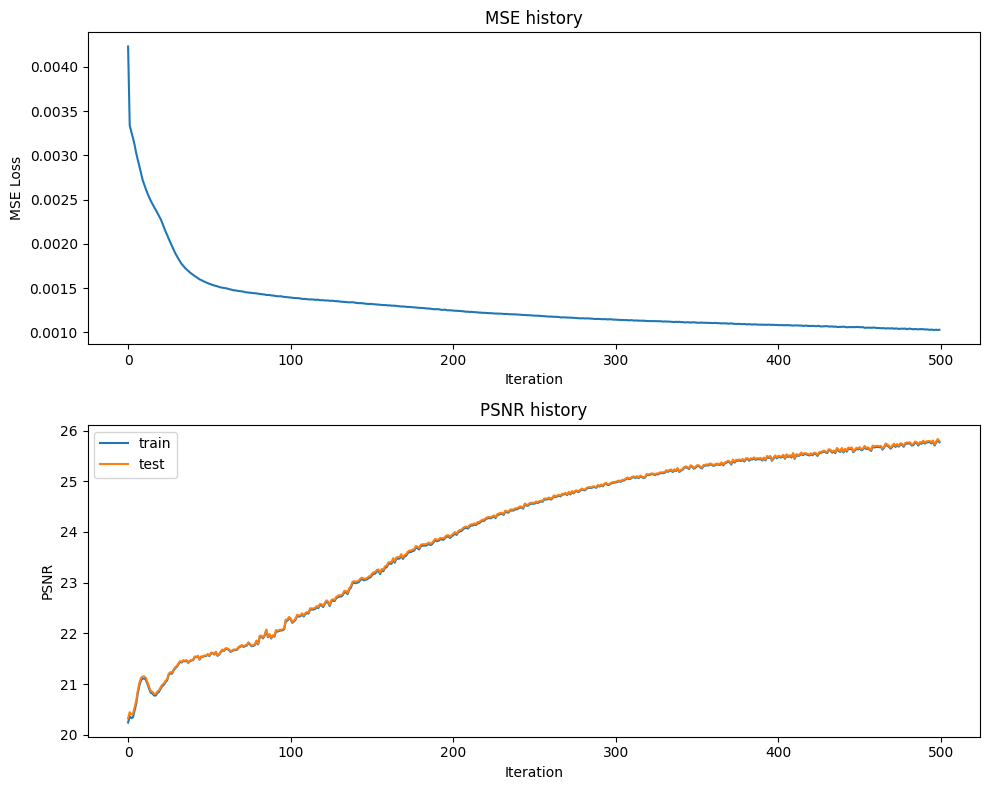

Final Test MSE 0.0013183880811208262
Final Test psnr 25.78926736201769


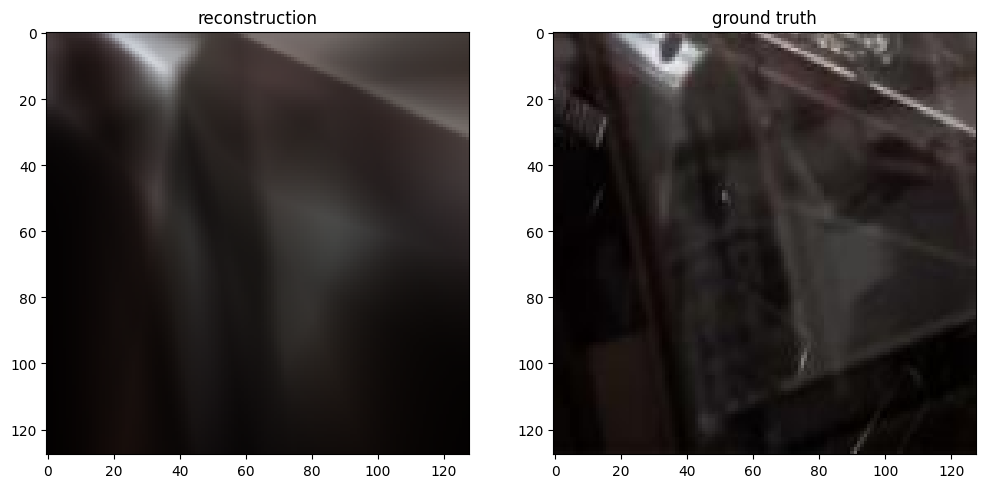

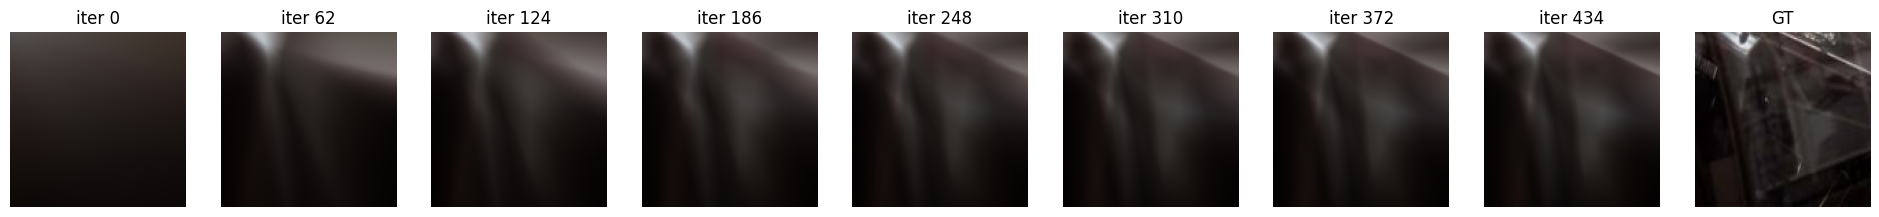

In [ ]:
# TODO Use train_wrapper to retrieve newly trained model and data that will be plotted below
result = train_wrapper(
    mapping="none",
    size=size,
    num_layers=num_layers,
    hidden_size=hidden_size,
    output_size=output_size,
    epochs=epochs,
    learning_rate=learning_rate,
    opt='SGD'
)

net = result['net']
train_psnr = result['train_psnrs']
test_psnr = result['test_psnrs']
train_loss = result['train_loss']
predicted_images = result['pred_imgs']

# TODO Use get_input_features to retrieve X_test, y_test
B_dict = get_B_dict(size)
_, _, X_test, y_test = get_input_features(B_dict, "none")

plot_training_curves(train_loss, train_psnr, test_psnr)
plot_reconstruction(net.forward(X_test), y_test)
plot_reconstruction_progress(predicted_images, y_test)

# Extra Credit - Adam Optimizer

#### Low Resolution Reconstruction - Adam - None Mapping

/var/folders/wh/xw47m9f92xz89krbf6pcs4nr0000gn/T/ipykernel_87981/2979632171.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_url)[..., :3] / 255.


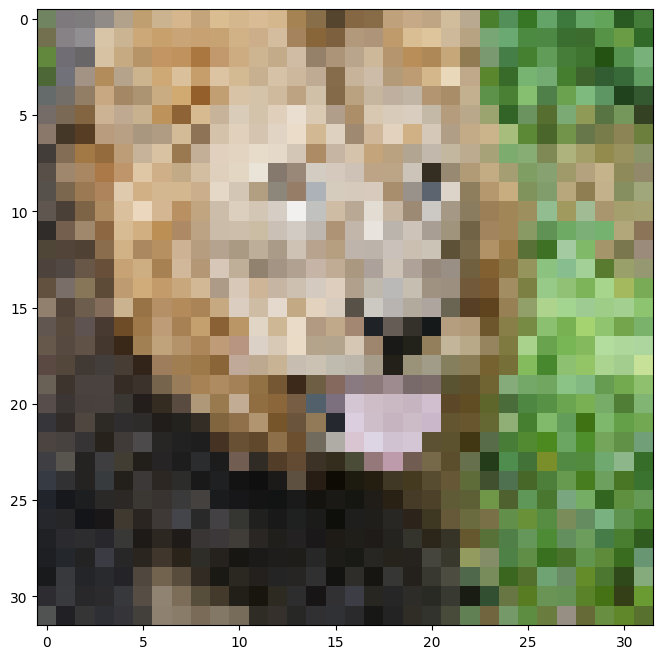

B_dict items:
	 none ()
	 basic (2, 2)
	 gauss_1.0 (16, 2)
	 gauss_10.0 (16, 2)


In [26]:
# load low-res image
size = 32
train_data, test_data = get_image(size)

B_dict = get_B_dict(size)

print('B_dict items:')
for k,v in B_dict.items():
    print('\t',k,np.array(v).shape)

100%|██████████| 500/500 [00:57<00:00,  8.63it/s]


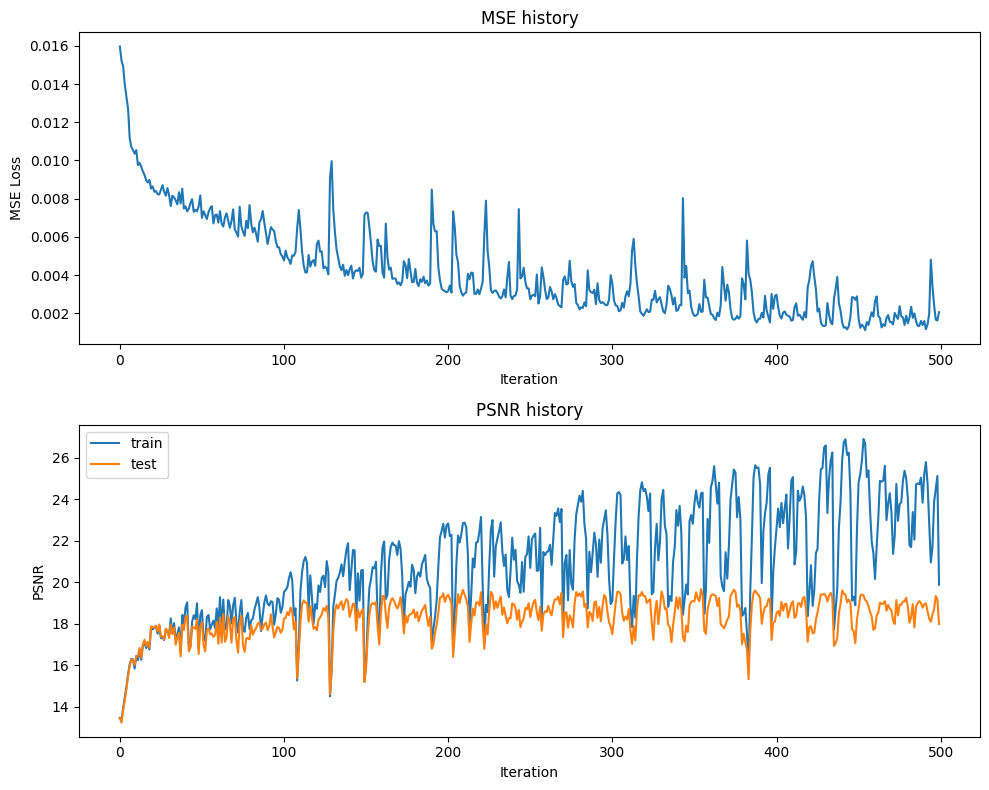

Final Test MSE 0.007950119332978699
Final Test psnr 17.985963567782658


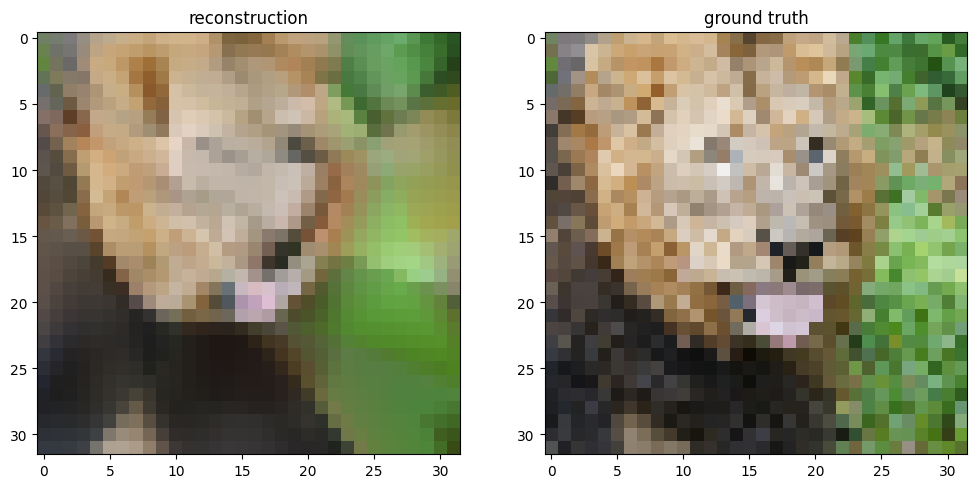

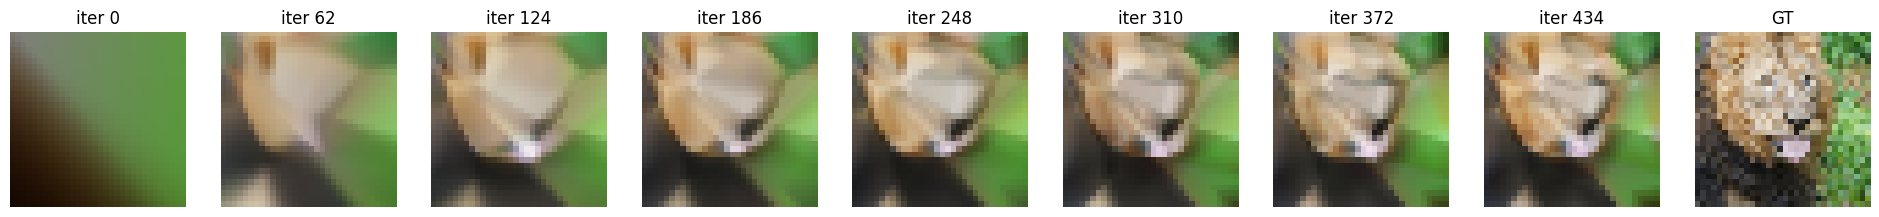

In [27]:
# Note: Adam typically needs a much smaller learning rate than SGD (e.g. 0.001)
adam_lr = 0.001

# TODO Use train_wrapper to retrieve newly trained model and data that will be plotted below
result = train_wrapper(
    mapping="none",
    size=size,
    num_layers=num_layers,
    hidden_size=hidden_size,
    output_size=output_size,
    epochs=epochs,
    learning_rate=adam_lr,
    opt='Adam'
)
net = result['net']
train_psnr = result['train_psnrs']
test_psnr = result['test_psnrs']
train_loss = result['train_loss']
predicted_images = result['pred_imgs']

# TODO Use get_input_features to retrieve X_test, y_test
# same as above
B_dict = get_B_dict(size)
_, _, X_test, y_test = get_input_features(B_dict, "none")

# plot results of experiment
plot_training_curves(train_loss, train_psnr, test_psnr)
plot_reconstruction(net.forward(X_test), y_test)
plot_reconstruction_progress(predicted_images, y_test)

#### Low Resolution Reconstruction - Adam - Various Input Mapping Strategies

In [28]:
# start training
outputs = {}
for k in tqdm(B_dict):
  print("training", k)
  outputs[k] = train_wrapper(k, size, num_layers, hidden_size, output_size, epochs, adam_lr, opt='Adam')

  0%|          | 0/4 [00:00<?, ?it/s]

training none


 25%|██▌       | 1/4 [00:58<02:56, 58.71s/it]

training basic


 50%|█████     | 2/4 [01:58<01:58, 59.31s/it]

training gauss_1.0


 75%|███████▌  | 3/4 [03:01<01:00, 60.80s/it]

training gauss_10.0


100%|██████████| 4/4 [04:03<00:00, 60.96s/it]


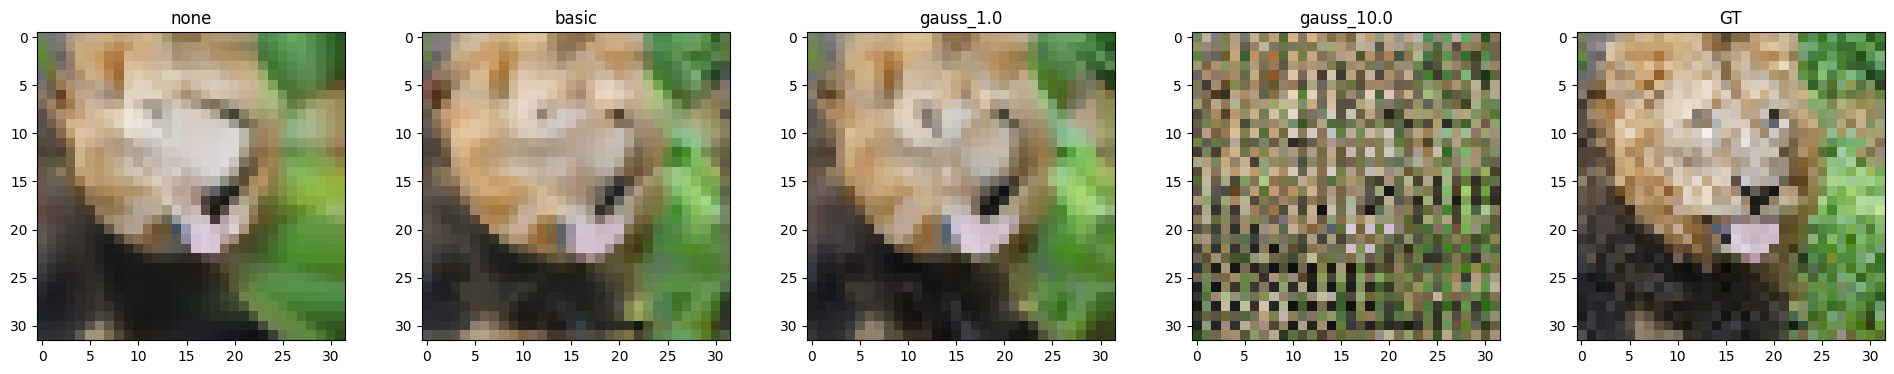

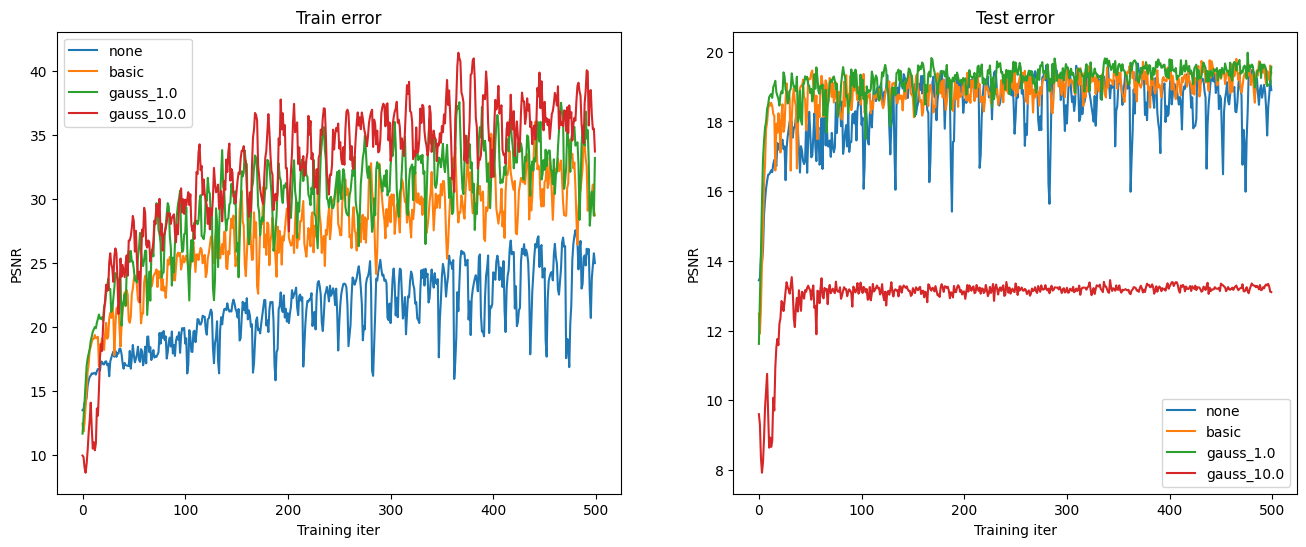

Final Test PSNR for none 18.89879427334121
Final Test PSNR for basic 19.386055288927903
Final Test PSNR for gauss_1.0 19.56558011160415
Final Test PSNR for gauss_10.0 13.105973089298944


In [29]:
# if you did everything correctly so far, this should output a nice figure you can use in your report
plot_feature_mapping_comparison(outputs, y_test.reshape(size,size,3))

#### High Resolution Reconstruction - Adam - Various Input Mapping Strategies

Repeat the previous experiment, but at the higher resolution. We have you first experiment with the lower resolution since it is faster to train and debug. Additionally, you will see how the mapping strategies perform better or worse at the two different input resolutions. 

/var/folders/wh/xw47m9f92xz89krbf6pcs4nr0000gn/T/ipykernel_87981/2979632171.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(image_url)[..., :3] / 255.


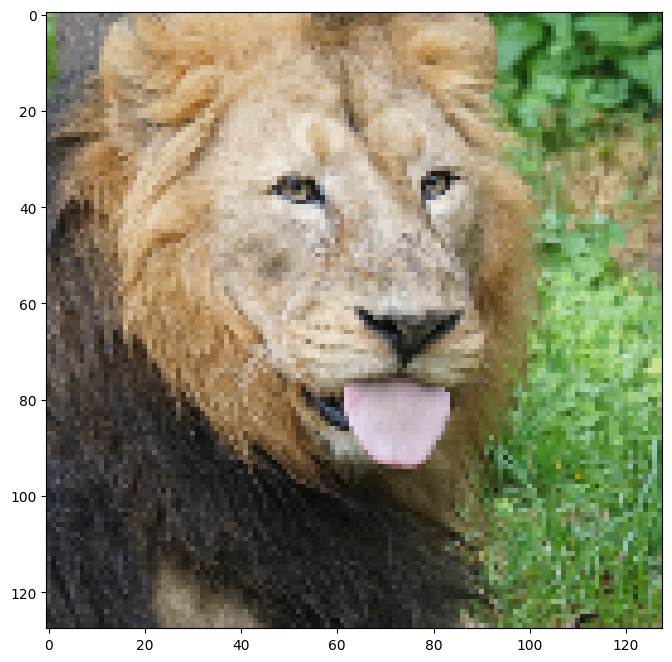

B_dict items:
	 none ()
	 basic (2, 2)
	 gauss_1.0 (64, 2)
	 gauss_10.0 (64, 2)


  0%|          | 0/4 [00:00<?, ?it/s]

training none


 25%|██▌       | 1/4 [15:33<46:39, 933.21s/it]

training basic


 50%|█████     | 2/4 [30:54<30:52, 926.32s/it]

training gauss_1.0


 75%|███████▌  | 3/4 [49:28<16:51, 1011.92s/it]

training gauss_10.0


100%|██████████| 4/4 [1:07:39<00:00, 1014.91s/it]


In [43]:
# load image
size = 128
train_data, test_data = get_image(size)

B_dict = get_B_dict(size)

print('B_dict items:')
for k,v in B_dict.items():
    print('\t',k,np.array(v).shape)

# start training
outputs = {}
for k in tqdm(B_dict):
  print("training", k)
  outputs[k] = train_wrapper(k, size, num_layers, hidden_size, output_size, epochs, adam_lr, opt='Adam')

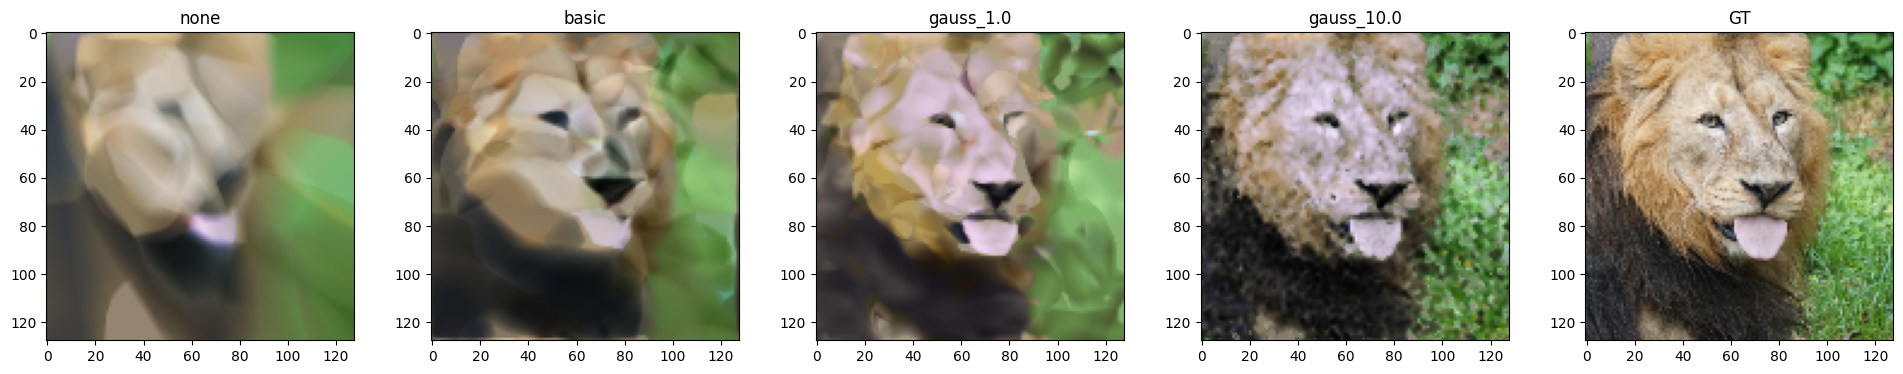

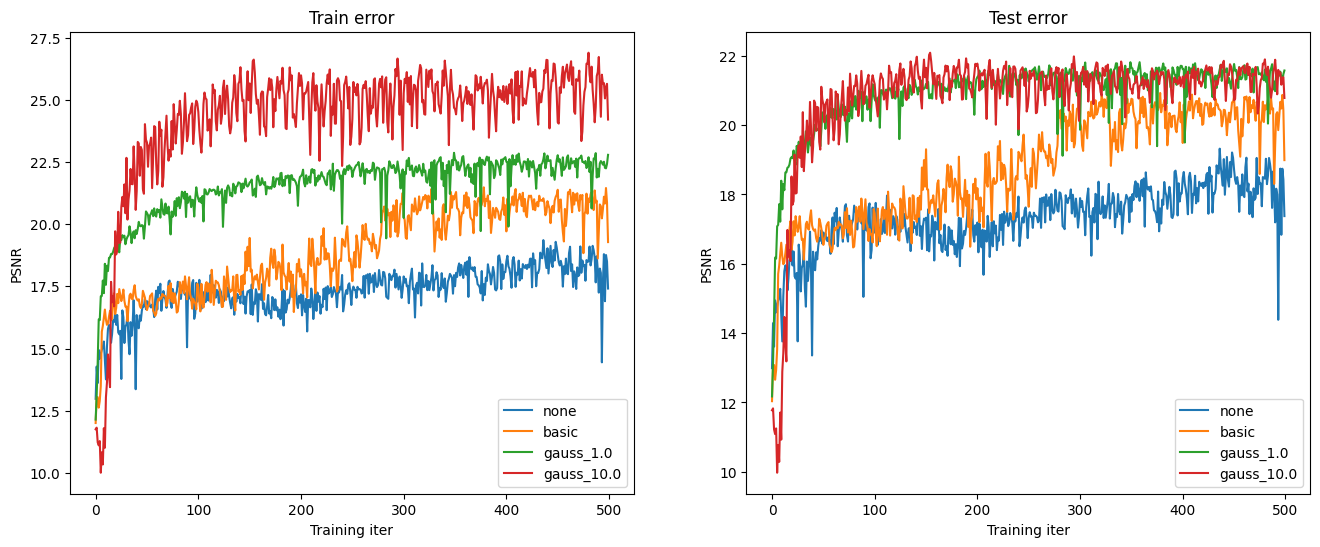

Final Test PSNR for none 17.37649205472269
Final Test PSNR for basic 18.991470589357725
Final Test PSNR for gauss_1.0 21.576750931673836
Final Test PSNR for gauss_10.0 20.784130374379846


In [44]:
_, _, _, y_test = get_input_features(B_dict, "none")  # for getting y_test

# if you did everything correctly so far, this should output a nice figure you can use in your report
plot_feature_mapping_comparison(outputs, y_test.reshape(size,size,3))